# EDA Lecture Demo

In [1]:
import polars as pl
import seaborn as sns
import numpy as np

sns.set_palette("colorblind")

hs = pl.read_csv('data/pivoted-ucb-data.csv')
hs

school,city,county,applied,admitted,attended
str,str,str,i64,i64,i64
"""A B MILLER HIGH SCHOOL""","""Fontana""","""San Bernardino""",25,3,null
"""ABLE CHARTER""","""Stockton""","""San Joaquin""",8,null,null
"""ABRAHAM LINCOLN HIGH SCHOOL""","""Los Angeles""","""Los Angeles""",48,11,4
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Francisco""","""San Francisco""",201,33,23
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Jose""","""Santa Clara""",56,8,3
…,…,…,…,…,…
"""YORBA LINDA HIGH SCHOOL""","""Yorba Linda""","""Orange""",86,8,3
"""YOSEMITE HIGH SCHOOL""","""Oakhurst""","""Madera""",7,null,null
"""YREKA HIGH SCHOOL""","""Yreka""","""Siskiyou""",8,null,null


In [2]:
hs.sort('applied', descending=True)

school,city,county,applied,admitted,attended
str,str,str,i64,i64,i64
"""DOUGHERTY VALLEY HIGH SCHOOL""","""San Ramon""","""Contra Costa""",542,44,32
"""DUBLIN HIGH SCHOOL""","""Dublin""","""Alameda""",435,40,27
"""ARCADIA HIGH SCHOOL""","""Arcadia""","""Los Angeles""",371,51,29
"""LOWELL HIGH SCHOOL""","""San Francisco""","""San Francisco""",363,42,29
"""AMERICAN HIGH SCHOOL""","""Fremont""","""Alameda""",348,25,20
…,…,…,…,…,…
"""VASQUEZ HIGH SCHOOL""","""Acton""","""Los Angeles""",5,null,null
"""VILLAGE ACADEMY HIGH SCHOOL""","""Pomona""","""Los Angeles""",5,null,null
"""WASHINGTON MIDDLE COLLEGE HS""","""West Sacramento""","""Yolo""",5,null,null


In [3]:
# Note that the original DataFrame is not modified by our exploration
hs

school,city,county,applied,admitted,attended
str,str,str,i64,i64,i64
"""A B MILLER HIGH SCHOOL""","""Fontana""","""San Bernardino""",25,3,null
"""ABLE CHARTER""","""Stockton""","""San Joaquin""",8,null,null
"""ABRAHAM LINCOLN HIGH SCHOOL""","""Los Angeles""","""Los Angeles""",48,11,4
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Francisco""","""San Francisco""",201,33,23
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Jose""","""Santa Clara""",56,8,3
…,…,…,…,…,…
"""YORBA LINDA HIGH SCHOOL""","""Yorba Linda""","""Orange""",86,8,3
"""YOSEMITE HIGH SCHOOL""","""Oakhurst""","""Madera""",7,null,null
"""YREKA HIGH SCHOOL""","""Yreka""","""Siskiyou""",8,null,null


In [4]:
len(hs)

1268

In [5]:
hs.shape

(1268, 6)

In [6]:
hs.shape[0]

1268

In [7]:
hs.shape[1]

6

Columns of dataframes are arrays, but a different kind of array (Apache Arrow arrays instead of the numpy arrays you're used to).

In [8]:
hs['applied']

applied
i64
25
8
48
201
56
…
86
7
8


In [9]:
hs['applied'].min()

5

In [10]:
hs['applied'].max()

542

In [11]:
hs['applied'].mean()

48.65299684542587

In [12]:
hs['applied'].std()

59.39564956744778

In [13]:
# Try uncommenting this line and running it: what happens and why?
# np.min(hs['applied'])

In [14]:
hs.sort('applied', descending=True)

school,city,county,applied,admitted,attended
str,str,str,i64,i64,i64
"""DOUGHERTY VALLEY HIGH SCHOOL""","""San Ramon""","""Contra Costa""",542,44,32
"""DUBLIN HIGH SCHOOL""","""Dublin""","""Alameda""",435,40,27
"""ARCADIA HIGH SCHOOL""","""Arcadia""","""Los Angeles""",371,51,29
"""LOWELL HIGH SCHOOL""","""San Francisco""","""San Francisco""",363,42,29
"""AMERICAN HIGH SCHOOL""","""Fremont""","""Alameda""",348,25,20
…,…,…,…,…,…
"""VASQUEZ HIGH SCHOOL""","""Acton""","""Los Angeles""",5,null,null
"""VILLAGE ACADEMY HIGH SCHOOL""","""Pomona""","""Los Angeles""",5,null,null
"""WASHINGTON MIDDLE COLLEGE HS""","""West Sacramento""","""Yolo""",5,null,null


In [15]:
hs_enroll = pl.read_csv('data/pivoted-ucb-data-w-enrollment.csv')
hs_enroll

school,city,county,applied,admitted,attended,tot_enrolled,grade_12
str,str,str,i64,i64,i64,i64,i64
"""A B MILLER HIGH SCHOOL""","""Fontana""","""San Bernardino""",25,3,null,1961,485
"""ABLE CHARTER""","""Stockton""","""San Joaquin""",8,null,null,1191,73
"""ABRAHAM LINCOLN HIGH SCHOOL""","""Los Angeles""","""Los Angeles""",48,11,4,942,242
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Francisco""","""San Francisco""",201,33,23,2037,489
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Jose""","""Santa Clara""",56,8,3,1596,365
…,…,…,…,…,…,…,…
"""YORBA LINDA HIGH SCHOOL""","""Yorba Linda""","""Orange""",86,8,3,1584,409
"""YOSEMITE HIGH SCHOOL""","""Oakhurst""","""Madera""",7,null,null,557,133
"""YREKA HIGH SCHOOL""","""Yreka""","""Siskiyou""",8,null,null,636,139


## Selecting columns

In [16]:
hs.select('school', 'attended')

school,attended
str,i64
"""A B MILLER HIGH SCHOOL""",null
"""ABLE CHARTER""",null
"""ABRAHAM LINCOLN HIGH SCHOOL""",4
"""ABRAHAM LINCOLN HIGH SCHOOL""",23
"""ABRAHAM LINCOLN HIGH SCHOOL""",3
…,…
"""YORBA LINDA HIGH SCHOOL""",3
"""YOSEMITE HIGH SCHOOL""",null
"""YREKA HIGH SCHOOL""",null


In [17]:
hs.select(pl.col('school'), pl.col('attended'))

school,attended
str,i64
"""A B MILLER HIGH SCHOOL""",null
"""ABLE CHARTER""",null
"""ABRAHAM LINCOLN HIGH SCHOOL""",4
"""ABRAHAM LINCOLN HIGH SCHOOL""",23
"""ABRAHAM LINCOLN HIGH SCHOOL""",3
…,…
"""YORBA LINDA HIGH SCHOOL""",3
"""YOSEMITE HIGH SCHOOL""",null
"""YREKA HIGH SCHOOL""",null


In [18]:
hs.select(pl.col('school'), pl.col('attended') / 1000)

school,attended
str,f64
"""A B MILLER HIGH SCHOOL""",null
"""ABLE CHARTER""",null
"""ABRAHAM LINCOLN HIGH SCHOOL""",0.004
"""ABRAHAM LINCOLN HIGH SCHOOL""",0.023
"""ABRAHAM LINCOLN HIGH SCHOOL""",0.003
…,…
"""YORBA LINDA HIGH SCHOOL""",0.003
"""YOSEMITE HIGH SCHOOL""",null
"""YREKA HIGH SCHOOL""",null


In [19]:
hs_enroll = hs_enroll.with_columns(
    app_rate=pl.col('applied') / pl.col('grade_12')
)
hs_enroll

school,city,county,applied,admitted,attended,tot_enrolled,grade_12,app_rate
str,str,str,i64,i64,i64,i64,i64,f64
"""A B MILLER HIGH SCHOOL""","""Fontana""","""San Bernardino""",25,3,null,1961,485,0.051546
"""ABLE CHARTER""","""Stockton""","""San Joaquin""",8,null,null,1191,73,0.109589
"""ABRAHAM LINCOLN HIGH SCHOOL""","""Los Angeles""","""Los Angeles""",48,11,4,942,242,0.198347
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Francisco""","""San Francisco""",201,33,23,2037,489,0.411043
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Jose""","""Santa Clara""",56,8,3,1596,365,0.153425
…,…,…,…,…,…,…,…,…
"""YORBA LINDA HIGH SCHOOL""","""Yorba Linda""","""Orange""",86,8,3,1584,409,0.210269
"""YOSEMITE HIGH SCHOOL""","""Oakhurst""","""Madera""",7,null,null,557,133,0.052632
"""YREKA HIGH SCHOOL""","""Yreka""","""Siskiyou""",8,null,null,636,139,0.057554


In [20]:
hs_enroll.sort('app_rate', descending=True)

school,city,county,applied,admitted,attended,tot_enrolled,grade_12,app_rate
str,str,str,i64,i64,i64,i64,i64,f64
"""ALLIANCE MIT 6-12 COMPLEX""","""Sun Valley""","""Los Angeles""",19,null,null,null,null,null
"""ANTELOPE HIGH SCHOOL""","""Antelope""","""Sacramento""",37,3,null,null,null,null
"""BAYFRONT CHARTER HIGH SCHOOL""","""Chula Vista""","""San Diego""",7,null,null,null,null,null
"""BOYLE HEIGHTS STEM MAGNET HIGH…","""Los Angeles""","""Los Angeles""",11,null,null,null,null,null
"""CA ONLINE PUBLIC SCH CENTRAL V…","""Ripon""","""San Joaquin""",6,null,null,null,null,null
…,…,…,…,…,…,…,…,…
"""SHAFTER HIGH SCHOOL""","""Shafter""","""Kern""",7,null,null,1655,431,0.016241
"""PERRIS HIGH SCHOOL""","""Perris""","""Riverside""",7,3,null,2106,497,0.014085
"""EXCELSIOR CHARTER SCHL VICTORV…","""Victorville""","""San Bernardino""",5,null,null,2120,371,0.013477


In [21]:
hs_enroll = hs_enroll.filter(pl.col('app_rate').is_not_null())
hs_enroll.sort('app_rate', descending=True)

school,city,county,applied,admitted,attended,tot_enrolled,grade_12,app_rate
str,str,str,i64,i64,i64,i64,i64,f64
"""GIRLS ACADEMIC LEADERSHIP ACAD""","""Los Angeles""","""Los Angeles""",40,7,null,66,16,2.5
"""MCFARLAND HIGH SCHOOL""","""Mcfarland""","""Kern""",16,null,null,14,10,1.6
"""ALAMEDA SCIENCE & TECHNICAL IN…","""Alameda""","""Alameda""",42,7,6,167,29,1.448276
"""SCIENCE ACADEMY STEM MAGNET""","""North Hollywood""","""Los Angeles""",38,5,null,513,33,1.151515
"""MIDDLE COLLEGE HIGH SCHOOL""","""San Pablo""","""Contra Costa""",50,10,9,283,60,0.833333
…,…,…,…,…,…,…,…,…
"""SHAFTER HIGH SCHOOL""","""Shafter""","""Kern""",7,null,null,1655,431,0.016241
"""PERRIS HIGH SCHOOL""","""Perris""","""Riverside""",7,3,null,2106,497,0.014085
"""EXCELSIOR CHARTER SCHL VICTORV…","""Victorville""","""San Bernardino""",5,null,null,2120,371,0.013477


In [22]:
hs_enroll = hs_enroll.filter(pl.col('app_rate') <= 1)
hs_enroll.sort('app_rate', descending=True)

school,city,county,applied,admitted,attended,tot_enrolled,grade_12,app_rate
str,str,str,i64,i64,i64,i64,i64,f64
"""MIDDLE COLLEGE HIGH SCHOOL""","""San Pablo""","""Contra Costa""",50,10,9,283,60,0.833333
"""MONTA VISTA HIGH SCHOOL""","""Cupertino""","""Santa Clara""",321,33,25,1636,421,0.76247
"""GRETCHEN WHITNEY HIGH SCHOOL""","""Cerritos""","""Los Angeles""",119,23,13,1018,163,0.730061
"""CALIFORNIA ACAD MATH & SCIENCE""","""Carson""","""Los Angeles""",115,24,11,667,163,0.705521
"""LYNBROOK HIGH SCHOOL""","""San Jose""","""Santa Clara""",314,34,25,1720,448,0.700893
…,…,…,…,…,…,…,…,…
"""SHAFTER HIGH SCHOOL""","""Shafter""","""Kern""",7,null,null,1655,431,0.016241
"""PERRIS HIGH SCHOOL""","""Perris""","""Riverside""",7,3,null,2106,497,0.014085
"""EXCELSIOR CHARTER SCHL VICTORV…","""Victorville""","""San Bernardino""",5,null,null,2120,371,0.013477


In [23]:
hs_enroll['app_rate'].describe()

statistic,value
str,f64
"""count""",1229.0
"""null_count""",0.0
"""mean""",0.160831
"""std""",0.133873
"""min""",0.009901
"""25%""",0.068921
"""50%""",0.112676
"""75%""",0.204082
"""max""",0.833333


In [24]:
hs_enroll.describe()

statistic,school,city,county,applied,admitted,attended,tot_enrolled,grade_12,app_rate
str,str,str,str,f64,f64,f64,f64,f64,f64
"""count""","""1229""","""1229""","""1229""",1229.0,811.0,489.0,1229.0,1229.0,1229.0
"""null_count""","""0""","""0""","""0""",0.0,418.0,740.0,0.0,0.0,0.0
"""mean""",null,null,null,49.63629,9.467324,7.408998,1453.454841,335.988609,0.160831
"""std""",null,null,null,60.030817,8.858691,6.015383,884.914242,213.542671,0.133873
"""min""","""A B MILLER HIGH SCHOOL""","""Acton""","""Alameda""",5.0,3.0,3.0,39.0,14.0,0.009901
"""25%""",null,null,null,15.0,4.0,3.0,675.0,133.0,0.068921
"""50%""",null,null,null,30.0,6.0,5.0,1477.0,337.0,0.112676
"""75%""",null,null,null,54.0,11.0,9.0,2021.0,485.0,0.204082
"""max""","""YUCAIPA SENIOR HIGH SCHOOL""","""Yucaipa""","""Yuba""",542.0,73.0,38.0,7548.0,1392.0,0.833333


<Axes: xlabel='app_rate'>

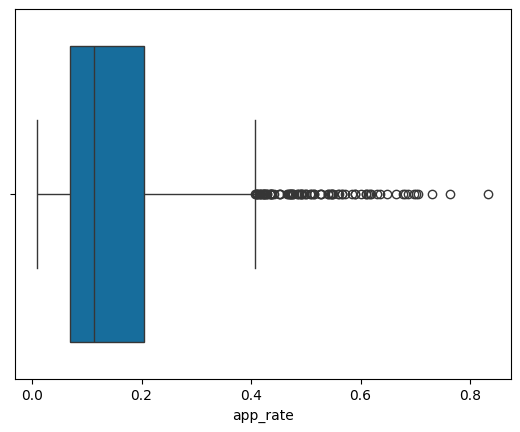

In [25]:
sns.boxplot(hs_enroll, x='app_rate')

<Axes: xlabel='app_rate', ylabel='Count'>

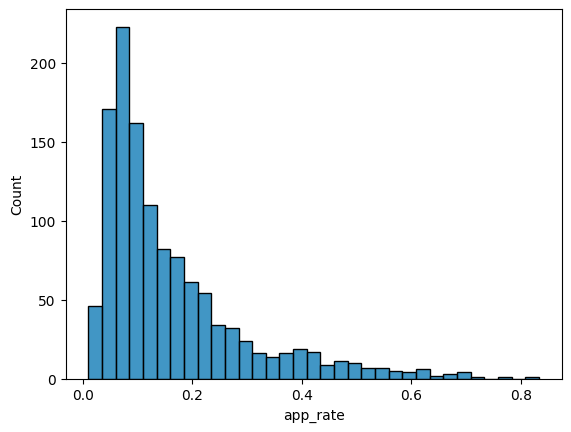

In [26]:
sns.histplot(hs_enroll, x='app_rate')

In [27]:
full = pl.read_csv('data/pivoted-ucb-data-w-everything.csv')
full

school,city,county,applied,admitted,attended,tot_enrolled,grade_12,is_charter,pct_free_reduced,dist_to_ucb_miles
str,str,str,i64,i64,i64,i64,i64,str,f64,f64
"""A B MILLER HIGH SCHOOL""","""Fontana""","""San Bernardino""",25,3,null,1961,485,"""N""",0.685365,372.941684
"""ABLE CHARTER""","""Stockton""","""San Joaquin""",8,null,null,1191,73,"""Y""",0.678421,52.249325
"""ABRAHAM LINCOLN HIGH SCHOOL""","""Los Angeles""","""Los Angeles""",48,11,4,942,242,"""N""",0.832272,346.780088
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Francisco""","""San Francisco""",201,33,23,2037,489,"""N""",0.450172,14.878894
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Jose""","""Santa Clara""",56,8,3,1596,365,"""N""",0.469298,41.786639
…,…,…,…,…,…,…,…,…,…,…
"""YORBA LINDA HIGH SCHOOL""","""Yorba Linda""","""Orange""",86,8,3,1584,409,"""N""",0.180556,371.43283
"""YOSEMITE HIGH SCHOOL""","""Oakhurst""","""Madera""",7,null,null,557,133,"""N""",0.479354,148.850295
"""YREKA HIGH SCHOOL""","""Yreka""","""Siskiyou""",8,null,null,636,139,"""N""",0.460692,268.05834


<Axes: xlabel='dist_to_ucb_miles'>

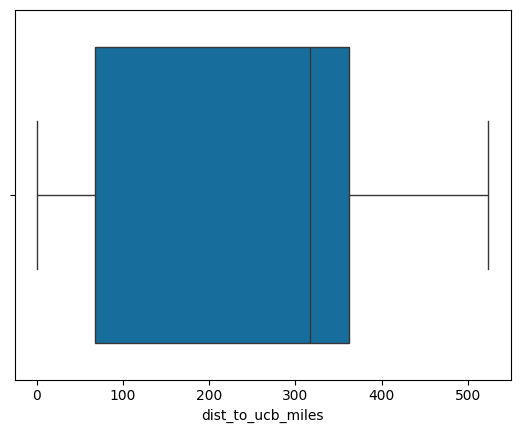

In [28]:
sns.boxplot(full, x='dist_to_ucb_miles')

<Axes: xlabel='dist_to_ucb_miles', ylabel='Count'>

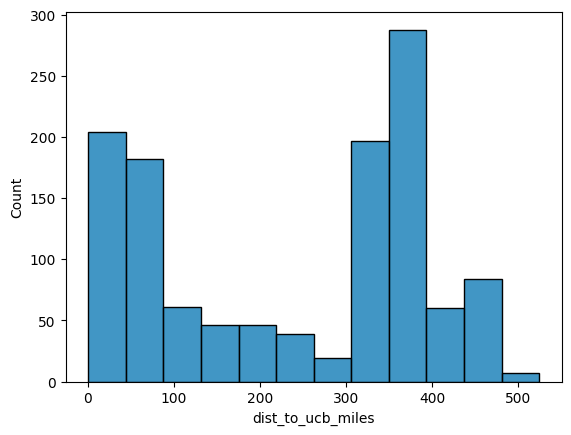

In [29]:
sns.histplot(full, x='dist_to_ucb_miles')

<Axes: xlabel='dist_to_ucb_miles', ylabel='Count'>

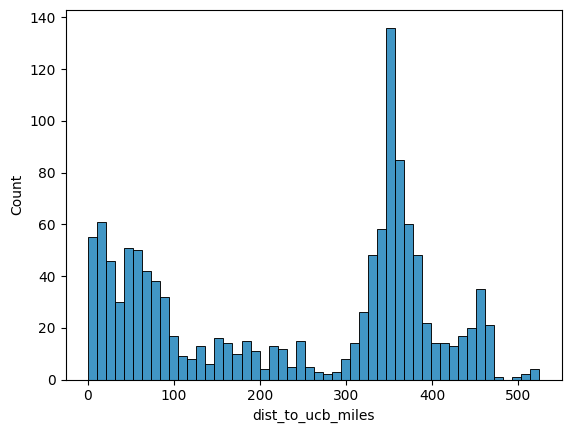

In [30]:
sns.histplot(full, x='dist_to_ucb_miles', bins=50)

In [31]:
city_counts = full['city'].value_counts().sort('count', descending=True)
city_counts

city,count
str,u32
"""Los Angeles""",112
"""San Diego""",41
"""San Jose""",31
"""Sacramento""",28
"""Oakland""",28
…,…
"""Lost Hills""",1
"""Piedmont""",1
"""Brawley""",1


In [32]:
city_counts[:10]

city,count
str,u32
"""Los Angeles""",112
"""San Diego""",41
"""San Jose""",31
"""Sacramento""",28
"""Oakland""",28
"""Stockton""",19
"""San Francisco""",18
"""Fresno""",17
"""Bakersfield""",16


In [33]:
# We need to repeat the modifications from original dataset!
# Why don't we need to filter out the null values this time?
full = (
    full
    .with_columns(app_rate=pl.col('applied') / pl.col('grade_12'))
    .filter(pl.col('app_rate') <= 1)
)
full

school,city,county,applied,admitted,attended,tot_enrolled,grade_12,is_charter,pct_free_reduced,dist_to_ucb_miles,app_rate
str,str,str,i64,i64,i64,i64,i64,str,f64,f64,f64
"""A B MILLER HIGH SCHOOL""","""Fontana""","""San Bernardino""",25,3,null,1961,485,"""N""",0.685365,372.941684,0.051546
"""ABLE CHARTER""","""Stockton""","""San Joaquin""",8,null,null,1191,73,"""Y""",0.678421,52.249325,0.109589
"""ABRAHAM LINCOLN HIGH SCHOOL""","""Los Angeles""","""Los Angeles""",48,11,4,942,242,"""N""",0.832272,346.780088,0.198347
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Francisco""","""San Francisco""",201,33,23,2037,489,"""N""",0.450172,14.878894,0.411043
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Jose""","""Santa Clara""",56,8,3,1596,365,"""N""",0.469298,41.786639,0.153425
…,…,…,…,…,…,…,…,…,…,…,…
"""YORBA LINDA HIGH SCHOOL""","""Yorba Linda""","""Orange""",86,8,3,1584,409,"""N""",0.180556,371.43283,0.210269
"""YOSEMITE HIGH SCHOOL""","""Oakhurst""","""Madera""",7,null,null,557,133,"""N""",0.479354,148.850295,0.052632
"""YREKA HIGH SCHOOL""","""Yreka""","""Siskiyou""",8,null,null,636,139,"""N""",0.460692,268.05834,0.057554
